In [1]:
import os
os.environ["OMP_NUM_THREADS"] = "1"
os.environ["MKL_NUM_THREADS"] = "1"
os.environ["OPENBLAS_NUM_THREADS"] = "1"
os.environ["NUMBA_NUM_THREADS"] = "1"
os.environ["VECLIB_MAXIMUM_THREADS"] = "1"


In [2]:
import pandas as pd
import numpy as np
import seaborn as sns
import shap
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report, roc_auc_score, precision_recall_curve, average_precision_score, auc, RocCurveDisplay
from Bio.SeqUtils.ProtParam import ProteinAnalysis
# VSCode Jupyter: increase output limit
from sklearn.model_selection import learning_curve
from IPython.core.interactiveshell import InteractiveShell
InteractiveShell.instance().ast_node_interactivity = "all"


c:\Users\ankit\AppData\Local\Programs\Python\Python312\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
train_df = pd.read_csv(r"D:\Thesis EGFR dataset\Dataset\Clustering\90 percent\data\train_data.csv")
val_df = pd.read_csv(r"D:\Thesis EGFR dataset\Dataset\Clustering\90 percent\data\val_data.csv")

In [4]:
amino_acids = "ACDEFGHIKLMNPQRSTVWY-"

def extract_features(sequence):
    sequence = sequence.upper()
    seq_len = len(sequence)
    counts = {aa: sequence.count(aa)/seq_len for aa in amino_acids}
    analysis = ProteinAnalysis(sequence.replace("-", ""))
    features = counts.copy()
    features["Hydrophobicity"] = analysis.gravy()
    features["Isoelectric point"] = analysis.isoelectric_point()
    features["Aromaticity"] = analysis.aromaticity()
    features["Instability index"] = analysis.instability_index()
    features["Molecular weight"] = analysis.molecular_weight()
    features["Charge"] = analysis.charge_at_pH(7.0)
    
    return features

In [5]:
empty_mask = train_df['CDR2 aligned'].str.replace("-", "").str.len() == 0

empty_sequences = train_df.loc[empty_mask, 'CDR2 aligned']
problem_rows = train_df.loc[empty_mask]
problem_rows.head()
empty_mask.sum()


,Cluster_name,CDR_sequence,Nanobody_id,Label,Sequence,CDR1,CDR2,CDR3,CDR1 aligned,CDR2 aligned,CDR3 aligned,Aligned Sequence


np.int64(0)

In [6]:
train_cdr1 = pd.DataFrame.from_records([extract_features(cdr) for cdr in train_df['CDR1 aligned']])
train_cdr2 = pd.DataFrame.from_records([extract_features(cdr) for cdr in train_df['CDR2 aligned']])
train_cdr3 = pd.DataFrame.from_records([extract_features(cdr) for cdr in train_df['CDR3 aligned']])


In [7]:
train_cdr1.columns = [f"CDR1_{aa}" for aa in train_cdr1.columns]
train_cdr2.columns = [f"CDR2_{aa}" for aa in train_cdr2.columns]
train_cdr3.columns = [f"CDR3_{aa}" for aa in train_cdr3.columns]

In [8]:
val_cdr1 = pd.DataFrame.from_records([extract_features(cdr) for cdr in val_df['CDR1 aligned']])
val_cdr2 = pd.DataFrame.from_records([extract_features(cdr) for cdr in val_df['CDR2 aligned']])
val_cdr3 = pd.DataFrame.from_records([extract_features(cdr) for cdr in val_df['CDR3 aligned']])


In [9]:
val_cdr1.columns = [f"CDR1_{aa}" for aa in val_cdr1.columns]
val_cdr2.columns = [f"CDR2_{aa}" for aa in val_cdr2.columns]
val_cdr3.columns = [f"CDR3_{aa}" for aa in val_cdr3.columns]


In [10]:
x_train = pd.concat([train_cdr1, train_cdr2, train_cdr3], axis=1)
y_train = train_df['Label'].values
x_val = pd.concat([val_cdr1, val_cdr2, val_cdr3], axis=1)
y_val = val_df['Label'].values


In [11]:
clf = RandomForestClassifier(
    n_estimators=300,
    max_depth=6,              
    min_samples_leaf=3,       
    max_features="sqrt",
    class_weight="balanced",
    random_state=42
)
clf.fit(x_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",300
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",6
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",3
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric(y_

In [12]:
print(type(clf))

<class 'sklearn.ensemble._forest.RandomForestClassifier'>


In [13]:
print("Train columns:", x_train.columns[:5])
print("Val columns:", x_val.columns[:5])


Train columns: Index(['CDR1_A', 'CDR1_C', 'CDR1_D', 'CDR1_E', 'CDR1_F'], dtype='object')
Val columns: Index(['CDR1_A', 'CDR1_C', 'CDR1_D', 'CDR1_E', 'CDR1_F'], dtype='object')


In [14]:
x_val = x_val[x_train.columns]

In [15]:
y_pred = clf.predict(x_val)
y_scores = clf.predict_proba(x_val)[:, 1]
print("Accuracy:", accuracy_score(y_val, y_pred))
print("Precision:", precision_score(y_val, y_pred))
print("Recall:", recall_score(y_val, y_pred))
print("F1 Score:", f1_score(y_val, y_pred))
print("\nConfusion Matrix:\n", confusion_matrix(y_val, y_pred))
print("\nClassification Report:\n", classification_report(y_val, y_pred))
print("\nROC AUC Score:", roc_auc_score(y_val, clf.predict_proba(x_val)[:, 1]))

Accuracy: 0.5850943128634236
Precision: 0.5884445709406575
Recall: 0.5828869467155342
F1 Score: 0.5856525741802988

Confusion Matrix:
 [[4116 2892]
 [2959 4135]]

Classification Report:
               precision    recall  f1-score   support

           0       0.58      0.59      0.58      7008
           1       0.59      0.58      0.59      7094

    accuracy                           0.59     14102
   macro avg       0.59      0.59      0.59     14102
weighted avg       0.59      0.59      0.59     14102


ROC AUC Score: 0.6217555304308869


In [16]:
# Training predictions
y_train_pred = clf.predict(x_train)

print("Training Accuracy:", accuracy_score(y_train, y_train_pred))
print("Validation Accuracy:", accuracy_score(y_val, y_pred))

Training Accuracy: 0.5909836895957856
Validation Accuracy: 0.5850943128634236


<Figure size 640x480 with 0 Axes>

Text(0.5, 0, 'Training Set Size')

Text(0, 0.5, 'Accuracy')

Text(0.5, 1.0, 'Learning Curve')

(0.0, 1.0)

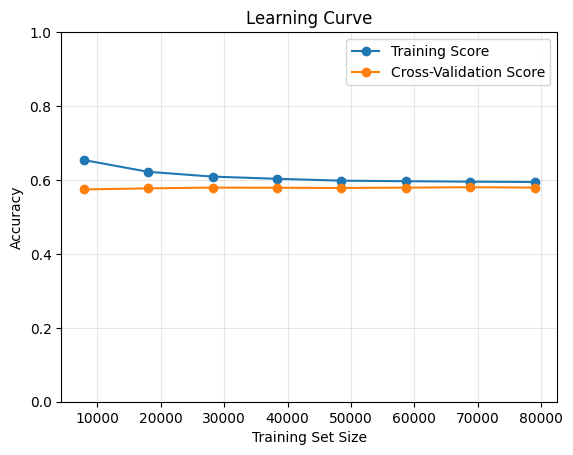

In [17]:
train_sizes, train_scores, val_scores = learning_curve(
    clf,
    x_train,
    y_train,
    cv=5,
    scoring="accuracy",
    n_jobs=-1,
    train_sizes=np.linspace(0.1, 1.0, 8),
    shuffle=True,
    random_state=42
)

train_mean = train_scores.mean(axis=1)
val_mean = val_scores.mean(axis=1)

plt.figure()
plt.plot(train_sizes, train_mean, marker="o")
plt.plot(train_sizes, val_mean, marker="o")
plt.xlabel("Training Set Size")
plt.ylabel("Accuracy")
plt.title("Learning Curve")
plt.legend(["Training Score", "Cross-Validation Score"])
plt.ylim(0, 1)
plt.grid(True, alpha=0.3)
plt.show()

In [17]:
from sklearn.dummy import DummyClassifier

dummy = DummyClassifier(strategy="most_frequent")
dummy.fit(x_train, y_train)
print("Baseline accuracy:", dummy.score(x_val, y_val))


,"strategy strategy: {""most_frequent"", ""prior"", ""stratified"", ""uniform"", ""constant""}, default=""prior""Strategy to use to generate predictions.* ""most_frequent"": the `predict` method always returns the most frequent class label in the observed `y` argument passed to `fit`. The `predict_proba` method returns the matching one-hot encoded vector.* ""prior"": the `predict` method always returns the most frequent class label in the observed `y` argument passed to `fit` (like ""most_frequent""). ``predict_proba`` always returns the empirical class distribution of `y` also known as the empirical class prior distribution.* ""stratified"": the `predict_proba` method randomly samples one-hot vectors from a multinomial distribution parametrized by the empirical class prior probabilities. The `predict` method returns the class label which got probability one in the one-hot vector of `predict_proba`. Each sampled row of both methods is therefore independent and identically distributed.* ""uniform"": generates predictions uniformly at random from the list of unique classes observed in `y`, i.e. each class has equal probability.* ""constant"": always predicts a constant label that is provided by the user. This is useful for metrics that evaluate a non-majority class. .. versionchanged:: 0.24 The default value of `strategy` has changed to ""prior"" in version 0.24.",'most_frequent'
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness to generate the predictions when``strategy='stratified'`` or ``strategy='uniform'``.Pass an int for reproducible output across multiple function calls.See :term:`Glossary `.",None
,"constant constant: int or str or array-like of shape (n_outputs,), default=NoneThe explicit constant as predicted by the ""constant"" strategy. Thisparameter is useful only for the ""constant"" strategy.",None


Baseline accuracy: 0.5030492128776061


In [18]:
precision, recall, thresholds = precision_recall_curve(y_val, y_scores)
ap = average_precision_score(y_val, y_scores)
print("Average precision:", ap)
pr_auc = auc(recall, precision)
print("PR AUC (AUC over PR curve):", pr_auc)

Average precision: 0.6132122131496405
PR AUC (AUC over PR curve): 0.613051226856522


<Figure size 640x480 with 0 Axes>

Text(0.5, 0, 'Recall')

Text(0, 0.5, 'Precision')

Text(0.5, 1.0, 'Precision-Recall curve (AP = 0.613)')

(0.0, 1.05)

(0.0, 1.0)

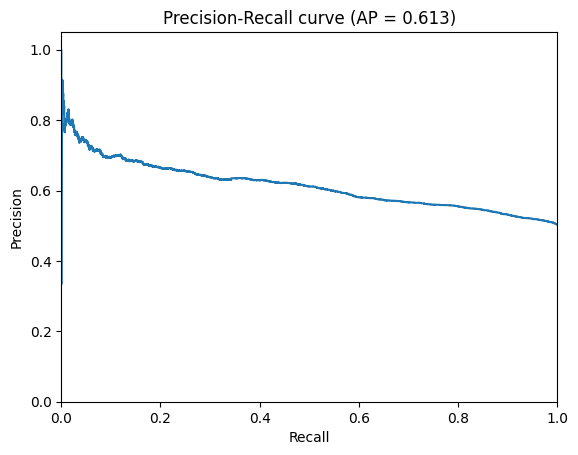

In [19]:
plt.figure()
plt.step(recall, precision, where="post")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title(f"Precision-Recall curve (AP = {ap:.3f})")
plt.ylim([0.0, 1.05])
plt.xlim([0.0, 1.0])
plt.show()



<Figure size 1000x600 with 0 Axes>

C:\Users\ankit\AppData\Local\Temp\ipykernel_11820\3492647688.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=feat_df.head(20), x='Importance', y='Feature', palette='viridis')


<Axes: xlabel='Importance', ylabel='Feature'>

Text(0.5, 1.0, 'Top 20 Feature Importances (Amino Acids in CDRs)')

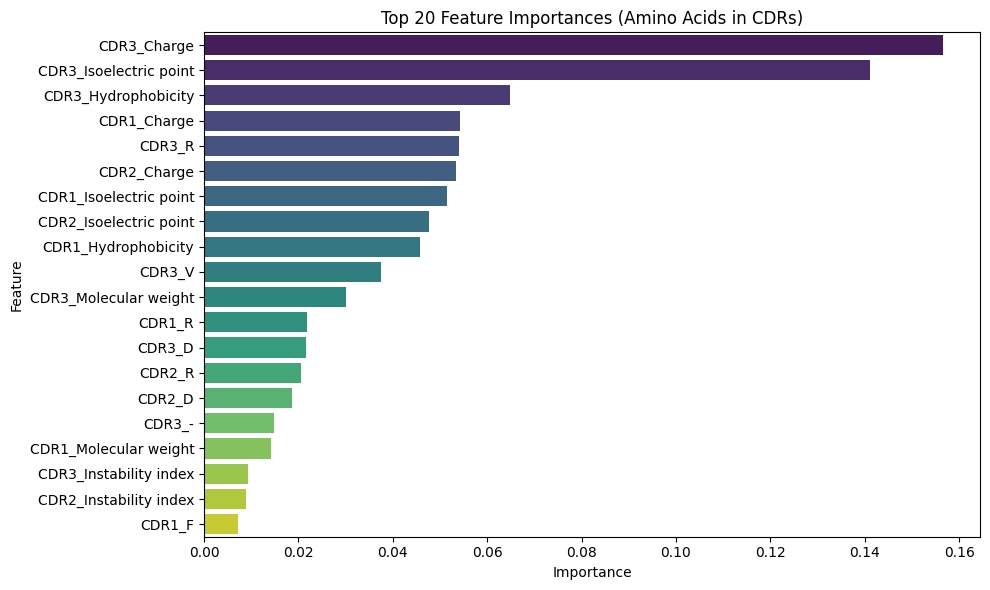

In [20]:
# Create feature importance DataFrame
feat_df = pd.DataFrame({
    'Feature': x_train.columns,
    'Importance': clf.feature_importances_
}).sort_values(by='Importance', ascending=False)

# Plot top 20 most important features
plt.figure(figsize=(10, 6))
sns.barplot(data=feat_df.head(20), x='Importance', y='Feature', palette='viridis')
plt.title('Top 20 Feature Importances (Amino Acids in CDRs)')
plt.tight_layout()
plt.show()

<Figure size 600x400 with 0 Axes>

C:\Users\ankit\AppData\Local\Temp\ipykernel_11820\3959690622.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=group_importance, x='Importance', y='Group', palette='Set2')


<Axes: xlabel='Importance', ylabel='Group'>

Text(0.5, 1.0, 'Grouped Feature Importance by CDR Region')

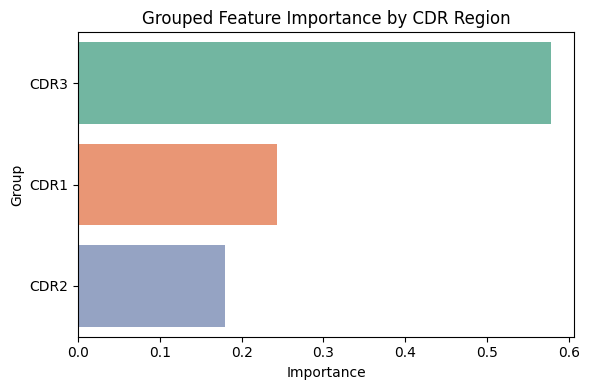

In [21]:
# Extract group from feature names
feat_df['Group'] = feat_df['Feature'].astype(str).str.extract(r'^(CDR\d+)_')

# Sum importance by group
group_importance = feat_df.groupby('Group')['Importance'].sum().reset_index().sort_values(by='Importance', ascending=False)

# Plot
plt.figure(figsize=(6, 4))
sns.barplot(data=group_importance, x='Importance', y='Group', palette='Set2')
plt.title('Grouped Feature Importance by CDR Region')
plt.tight_layout()
plt.show()


<Figure size 800x500 with 0 Axes>

C:\Users\ankit\AppData\Local\Temp\ipykernel_11820\2369169635.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=aa_importance, x='Importance', y='AA', palette='coolwarm')


<Axes: xlabel='Importance', ylabel='AA'>

Text(0.5, 1.0, 'Amino Acid Importance (All CDRs)')

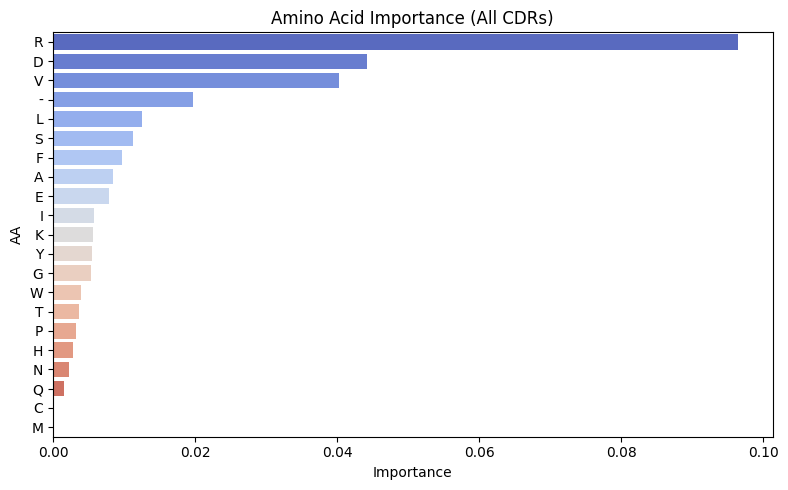

In [22]:
feat_df['AA'] = feat_df['Feature'].str.extract(r'_([A-Z\-])$')  # Extract last part (e.g., 'A' from 'CDR1_A')

aa_importance = feat_df.groupby('AA')['Importance'].sum().reset_index().sort_values(by='Importance', ascending=False)

# Plot
plt.figure(figsize=(8, 5))
sns.barplot(data=aa_importance, x='Importance', y='AA', palette='coolwarm')
plt.title('Amino Acid Importance (All CDRs)')
plt.tight_layout()
plt.show()


Test set evaluation

In [23]:

test_df = pd.read_csv(r"D:\Thesis EGFR dataset\Dataset\Clustering\90 percent\data\test_combined_data.csv")

In [24]:
test_cdr1 = pd.DataFrame.from_records([extract_features(cdr) for cdr in test_df['CDR1 aligned']])
test_cdr2 = pd.DataFrame.from_records([extract_features(cdr) for cdr in test_df['CDR2 aligned']])
test_cdr3 = pd.DataFrame.from_records([extract_features(cdr) for cdr in test_df['CDR3 aligned']])


In [25]:
test_cdr1.columns = [f"CDR1_{aa}" for aa in test_cdr1.columns]
test_cdr2.columns = [f"CDR2_{aa}" for aa in test_cdr2.columns]
test_cdr3.columns = [f"CDR3_{aa}" for aa in test_cdr3.columns]

In [26]:
x_test = pd.concat([test_cdr1, test_cdr2, test_cdr3], axis=1)
y_test = test_df['Label'].values
clusters_test = test_df["Cluster_name"].values

In [27]:
x_test = x_test[x_train.columns]

In [28]:
y_scores_test = clf.predict_proba(x_test)[:, 1]
# labels at fixed threshold
y_pred_test = (y_scores_test >= 0.5).astype(int)

# standard metrics
acc = accuracy_score(y_test, y_pred_test)
prec = precision_score(y_test, y_pred_test)
rec = recall_score(y_test, y_pred_test)
f1 = f1_score(y_test, y_pred_test)
cm = confusion_matrix(y_test, y_pred_test)

roc_auc = roc_auc_score(y_test, y_scores_test)
p, r, _ = precision_recall_curve(y_test, y_scores_test)
pr_auc = auc(r, p)

print("\n================ FULL TEST SET================\n")
print(f"Accuracy:  {acc:.3f}")
print(f"Precision: {prec:.3f}")
print(f"Recall:    {rec:.3f}")
print(f"F1:        {f1:.3f}")
print("\nConfusion matrix:")
print(cm)
print(f"\nROC-AUC (full test):   {roc_auc:.3f}")
print(f"PR-AUC (full test):    {pr_auc:.3f}")




================ FULL TEST SET================

Accuracy:  0.580
Precision: 0.582
Recall:    0.575
F1:        0.579

Confusion matrix:
[[8204 5812]
 [5979 8102]]

ROC-AUC (full test):   0.613
PR-AUC (full test):    0.600


In [29]:
print("\n================ Top-100 PREDICTIONS ONLY ================\n")
k =100
top_idx = np.argsort(-y_scores_test)[:k]
y_true_100 = y_test[top_idx]
tp_100 = np.sum(y_test[top_idx] == 1)
precision_100 = tp_100 / k
print(f"Precision@100: {precision_100:.3f}")
recall_100 = tp_100 / np.sum(y_test == 1)
print(f"Recall@100: {recall_100:.3f}")
n = len(y_test)
p = np.sum(y_test == 1)
ef_100 = (tp_100/k)/(p/n)
print(f"EF@100: {ef_100:.3f}")
assert len(clusters_test) == len(y_test)
diversity_100 = len(np.unique(clusters_test[top_idx]))
print(f"Diversity@100: {diversity_100}")
total_test_clusters = len(np.unique(clusters_test))
print("\nTotal clusters in test:", total_test_clusters)
normalized_diversity_100 = diversity_100 / total_test_clusters
print(f"Normalized diversity@100: {normalized_diversity_100:.3f}")
print("Top-K clusters:", np.unique(clusters_test[top_idx])[:10])

k1000 =1000
top1000_idx = np.argsort(-y_scores_test)[:k1000]
y_true_1000 = y_test[top1000_idx]
tp_1000 = np.sum(y_test[top1000_idx] == 1)
precision_1000 = tp_1000 / k1000
print(f"Precision@1000: {precision_1000:.3f}")


================ Top-100 PREDICTIONS ONLY ================

Precision@100: 0.760
Recall@100: 0.005
EF@100: 1.516
Diversity@100: 93

Total clusters in test: 26167
Normalized diversity@100: 0.004
Top-K clusters: [21040 27347 30996 35535 40711 49074 51628 51781 53849 53978]
Precision@1000: 0.706


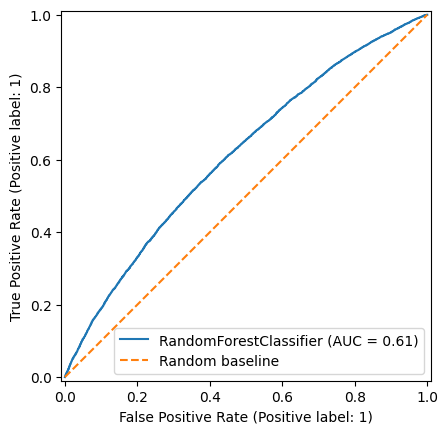

In [30]:
RocCurveDisplay.from_estimator(clf, x_test, y_test)
plt.plot([0, 1], [0, 1], linestyle="--", label="Random baseline")

plt.legend()
plt.show()

In [31]:
np.corrcoef(x_train["CDR3_Charge"], y_train)[0,1]


np.float64(0.1189619514367888)

SHAP values

In [32]:
x_top = x_test.iloc[top_idx]

shap_inter: (100, 81, 81, 2) X: (100, 81)


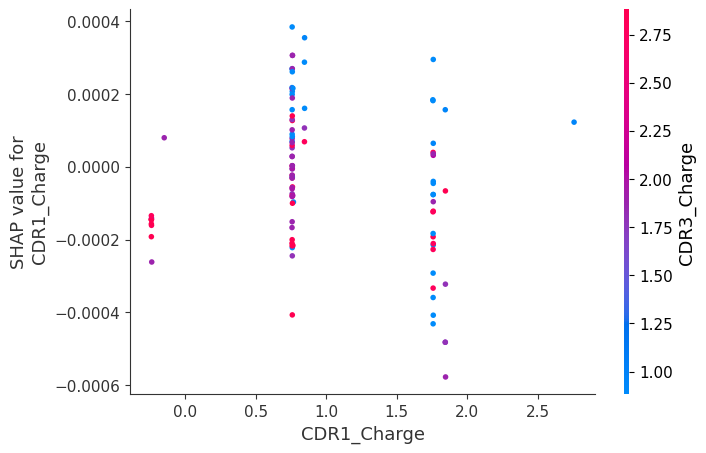

In [44]:
target_class = 1
explainer_interaction = shap.TreeExplainer(clf)

shap_inter = explainer_interaction.shap_interaction_values(x_top)

# Binary classification often returns a list by class
if isinstance(shap_inter, list):
    shap_inter = shap_inter[target_class]

print("shap_inter:", shap_inter.shape, "X:", x_top.shape)  # (n, p, p)

feature_names = list(x_top.columns)
i = feature_names.index("CDR1_Charge")
j = feature_names.index("CDR3_Charge")

target_class = 1  # positive class

# Extract interaction(i, j) for class 1 -> shape (n,)
ij = shap_inter[:, i, j, target_class]

# Build (n, p) matrix with only column i filled so dependence_plot can be used
sv_ij = np.zeros((x_top.shape[0], x_top.shape[1]))
sv_ij[:, i] = ij

shap.dependence_plot(
    i,                 # x-axis feature: CDR1_Charge
    sv_ij,             # y-axis: interaction contribution with CDR3_Charge
    x_top,
    interaction_index=j,   # color by CDR3_Charge
    feature_names=feature_names
)

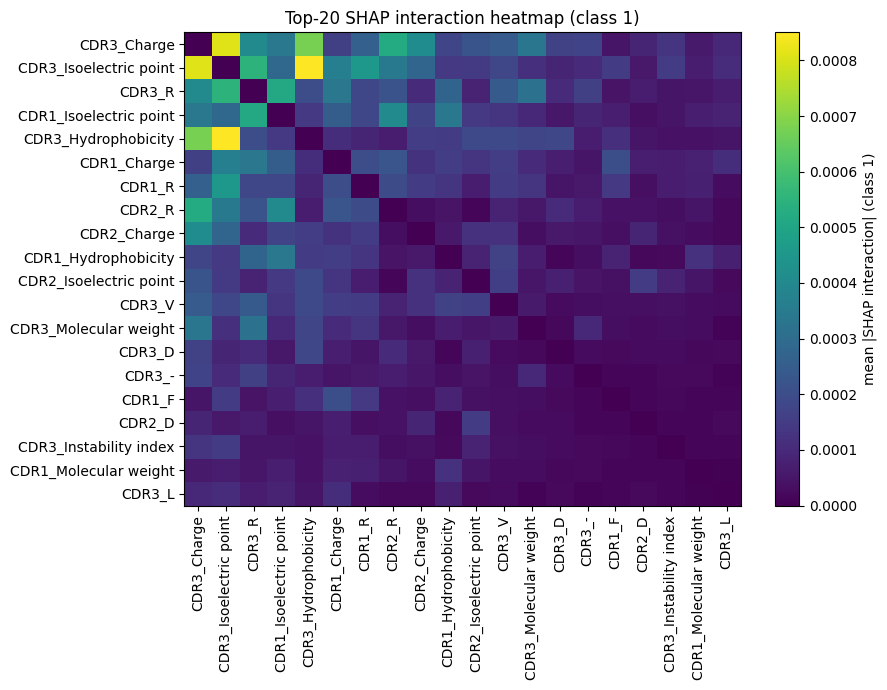

Top interaction features: ['CDR3_Charge', 'CDR3_Isoelectric point', 'CDR3_R', 'CDR1_Isoelectric point', 'CDR3_Hydrophobicity', 'CDR1_Charge', 'CDR1_R', 'CDR2_R', 'CDR2_Charge', 'CDR1_Hydrophobicity', 'CDR2_Isoelectric point', 'CDR3_V', 'CDR3_Molecular weight', 'CDR3_D', 'CDR3_-', 'CDR1_F', 'CDR2_D', 'CDR3_Instability index', 'CDR1_Molecular weight', 'CDR3_L']


In [46]:

def plot_topk_interaction_heatmap(shap_inter, X, target_class=1, k=20, zero_diag=True):
    feature_names = list(X.columns)
    SI = shap_inter[:, :, :, target_class]              # (n, p, p)
    M = np.abs(SI).mean(axis=0)                         # (p, p)

    if zero_diag:
        np.fill_diagonal(M, 0.0)

    # score each feature by its overall interaction strength
    scores = M.sum(axis=0) + M.sum(axis=1)
    top_idx = np.argsort(-scores)[:k]

    M_top = M[np.ix_(top_idx, top_idx)]
    names_top = [feature_names[i] for i in top_idx]

    plt.figure(figsize=(9, 7))
    im = plt.imshow(M_top, aspect="auto")
    plt.colorbar(im, label="mean |SHAP interaction| (class 1)")
    plt.xticks(range(k), names_top, rotation=90)
    plt.yticks(range(k), names_top)
    plt.title(f"Top-{k} SHAP interaction heatmap (class 1)")
    plt.tight_layout()
    plt.show()

    return names_top, M_top

top_features, M_top = plot_topk_interaction_heatmap(shap_inter, x_top, target_class=1, k=20)
print("Top interaction features:", top_features)

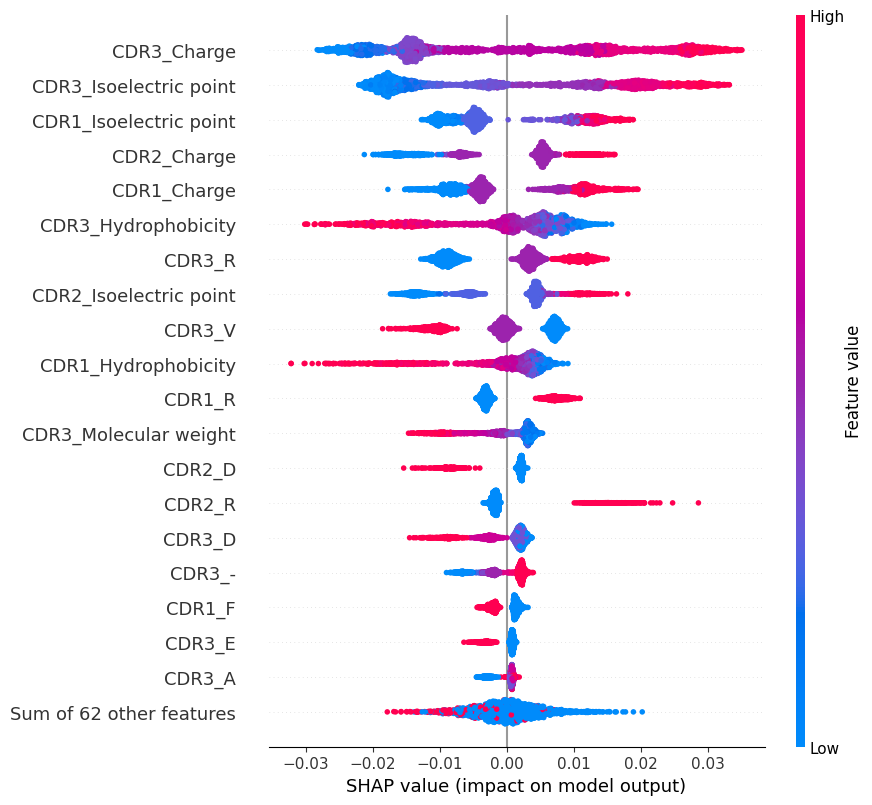

In [34]:
import shap

subset = x_test.sample(2000, random_state=42)

explainer = shap.TreeExplainer(clf)
sv = explainer(subset)          # sv is an Explanation

# If multi-class, select one class (e.g., 1)
if sv.values.ndim == 3:
    class_idx = 1
    sv = shap.Explanation(
        values=sv.values[:, :, class_idx],
        base_values=sv.base_values[:, class_idx],
        data=sv.data,
        feature_names=sv.feature_names
    )

shap.plots.beeswarm(sv, max_display=20)





Number of label 1 sequences in top-100: 76


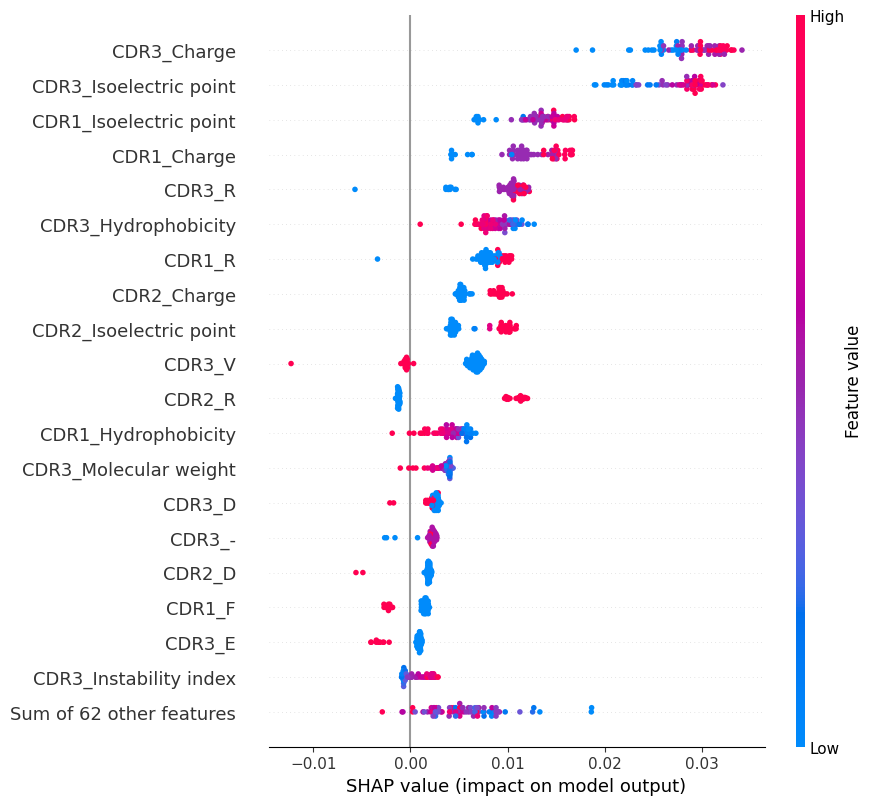

In [36]:
k =100
top_idx_shap = np.argsort(-y_scores_test)[:k]
top100_label1_idx = top_idx_shap[y_test[top_idx_shap] == 1]
print("Number of label 1 sequences in top-100:", len(top100_label1_idx))
subset_top100_pos = x_test.iloc[top100_label1_idx]
explainer_100 = shap.TreeExplainer(clf)
sv_100 = explainer_100(subset_top100_pos)

if sv_100.values.ndim == 3:
    class_idx = 1
    sv_100 = shap.Explanation(
        values=sv_100.values[:, :, class_idx],
        base_values=sv_100.base_values[:, class_idx],
        data=sv_100.data,
        feature_names=sv_100.feature_names
    )

shap.plots.beeswarm(sv_100, max_display=20)


Top-5 indices: [16637 14065 14066 13270 15949]
Top-5 scores : [0.66800986 0.66519445 0.66519445 0.66207937 0.66029003]
Top-5 labels : [1 1 1 1 1]

=== Rank 1 | x_test idx=16637 | score=0.6680 | y=1 ===


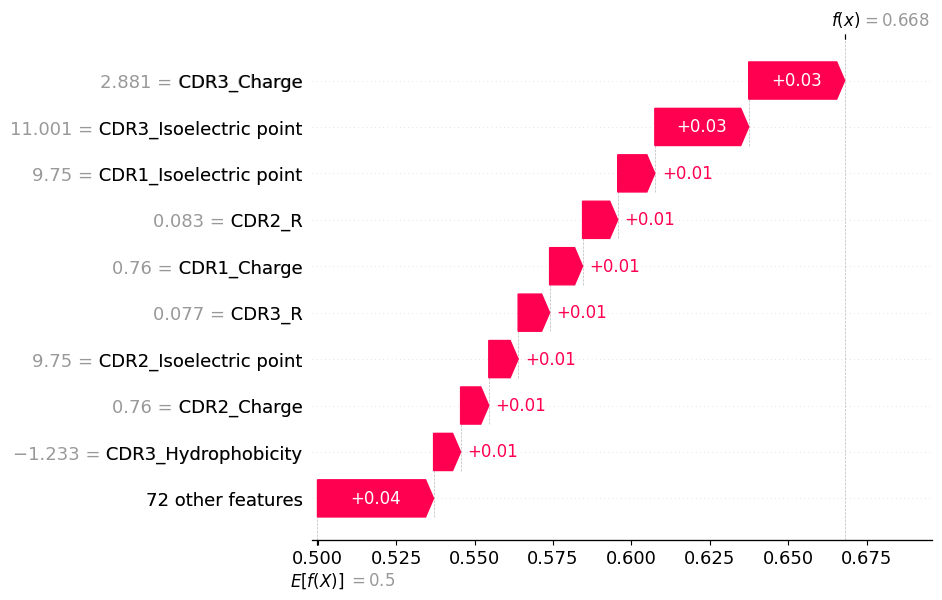


=== Rank 2 | x_test idx=14065 | score=0.6652 | y=1 ===


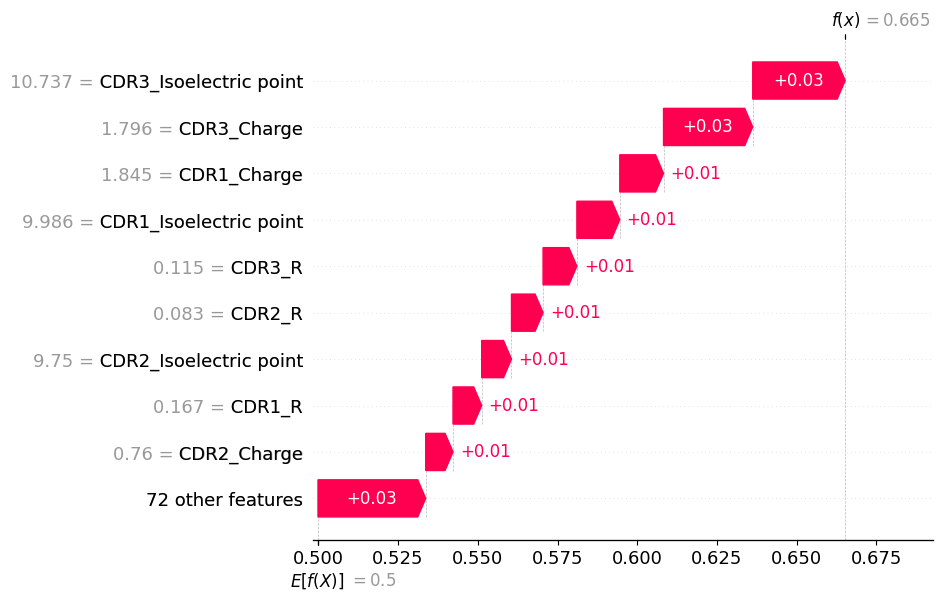


=== Rank 3 | x_test idx=14066 | score=0.6652 | y=1 ===


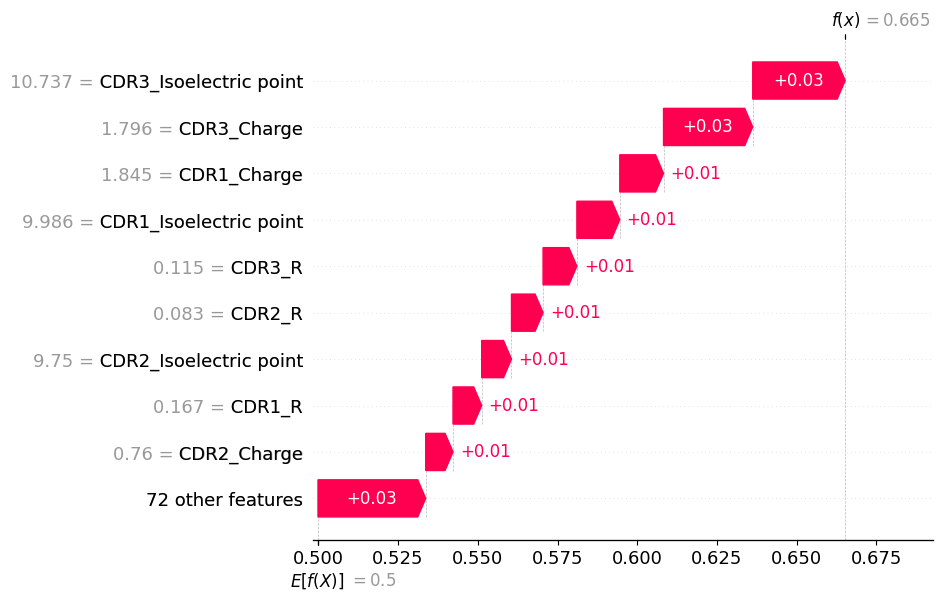


=== Rank 4 | x_test idx=13270 | score=0.6621 | y=1 ===


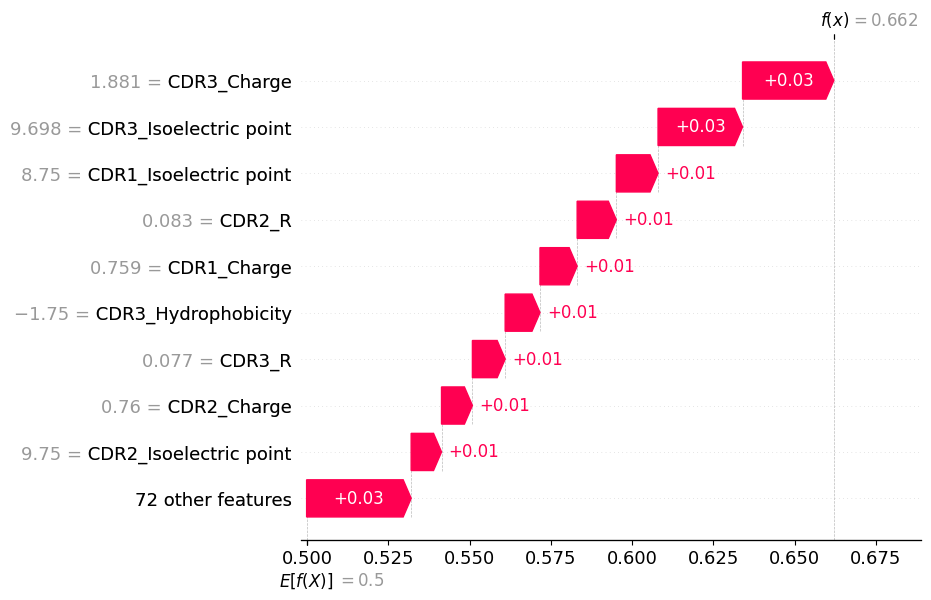


=== Rank 5 | x_test idx=15949 | score=0.6603 | y=1 ===


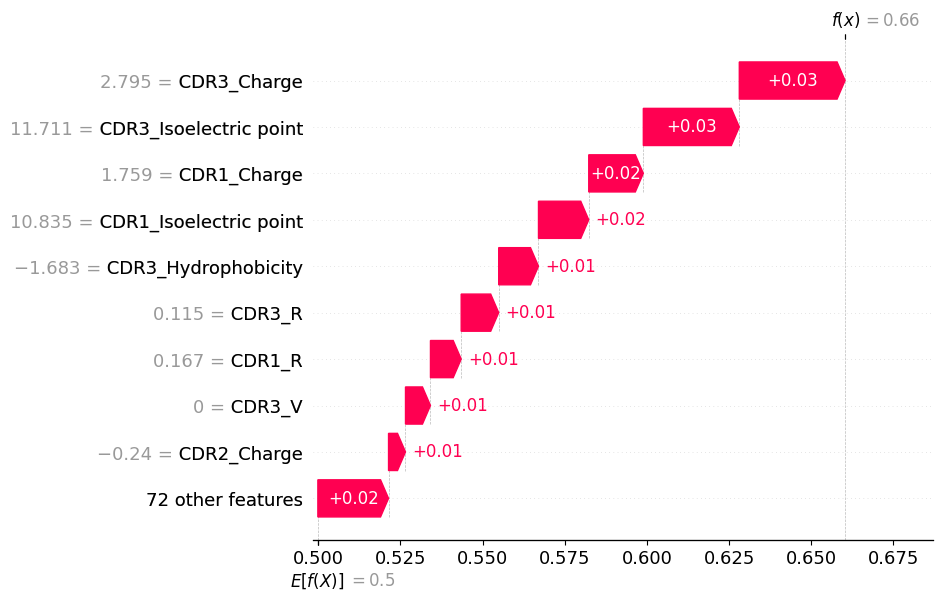

In [39]:
# --- 1) keep only true label = 1 ---
label1_idx = np.where(y_test == 1)[0]

# scores only for label1 samples
label1_scores = y_scores_test[label1_idx]

k_top = 5
top5_label1_local = np.argsort(-label1_scores)[:k_top]

# map back to original x_test indices
top5_idx = label1_idx[top5_label1_local]

top5_X = x_test.iloc[top5_idx]

print("Top-5 indices:", top5_idx)
print("Top-5 scores :", y_scores_test[top5_idx])
print("Top-5 labels :", y_test[top5_idx])   # should all be 1


# --- 2) Compute SHAP for those 5 rows (use the explainer you actually want) ---
# Prefer one explainer consistently:
explainer_5 = shap.TreeExplainer(clf)
sv_5 = explainer_5(top5_X)

# If multiclass/binary returns (n_samples, n_features, n_classes), select class 1
if sv_5.values.ndim == 3:
    class_idx = 1
    sv_5 = shap.Explanation(
        values=sv_5.values[:, :, class_idx],
        base_values=sv_5.base_values[:, class_idx],
        data=sv_5.data,
        feature_names=sv_5.feature_names
    )

# --- 3) Waterfall plots: top-10 SHAP features for each of the top-5 rows ---
for i in range(k_top):
    print(f"\n=== Rank {i+1} | x_test idx={top5_idx[i]} | score={y_scores_test[top5_idx[i]]:.4f} | y={y_test[top5_idx[i]]} ===")
    shap.plots.waterfall(sv_5[i], max_display=10)


Get the predicted + true label 1

In [47]:
top100_df =  test_df.iloc[top_idx].copy()
top100_df["y_true"] = y_test[top_idx]
top100_df["y_score"] = y_scores_test[top_idx]
top100_df["pred_label"] = y_pred_test[top_idx]


In [48]:
print(len(top_idx))

100


In [49]:
tp_top100_df = top100_df[
    (top100_df["y_true"] == 1) & (top100_df["pred_label"] == 1)
].copy()
tp_top100_df = tp_top100_df.rename(columns={"y_score": "pred_score"})

In [50]:
print(tp_top100_df.columns.tolist())


['Cluster_name', 'CDR_sequence', 'Nanobody_id', 'Label', 'Sequence', 'CDR1', 'CDR2', 'CDR3', 'CDR1 aligned', 'CDR2 aligned', 'CDR3 aligned', 'Aligned Sequence', 'y_true', 'pred_score', 'pred_label']


In [51]:
export_df = tp_top100_df[[
    "Cluster_name",
    "Nanobody_id",
    "Label",
    "pred_label",
    "pred_score",
    "Sequence",
    "CDR1",
    "CDR2",
    "CDR3",
    "CDR1 aligned",
    "CDR2 aligned",
    "CDR3 aligned",
    "Aligned Sequence"
]]


In [52]:
export_df.to_csv(r"D:\Thesis EGFR dataset\Dataset\Clustering\90 percent\Predictions\regularized_count_cdrs_chemical.csv", index=False)
print("Saved only confident predictions to confident_predictions.csv")
print("Number of confident predictions:", len(export_df))


Saved only confident predictions to confident_predictions.csv
Number of confident predictions: 76
